### Learning Objective

To model Kmeans Clustering, Agglomerative Hierarchical Clustering


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from numpy import unique
from sklearn.cluster import KMeans
from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn import metrics

In [ ]:
data = pd.read_csv('/content/Mall_Customers.csv', index_col=0)
data.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,,,,
1,Male,19,15,39
2,Male,21,15,81
3,Female,20,16,6
4,Female,23,16,77
5,Female,31,17,40


In [ ]:
data.drop(['Genre'], axis=1, inplace=True)
data.drop(['Age'], axis=1, inplace=True)

data.head()

,Annual Income (k$),Spending Score (1-100)
CustomerID,,
1,15,39
2,15,81
3,16,6
4,16,77
5,17,40


In [ ]:
data = data.sample(frac=1)
data.head()

,Annual Income (k$),Spending Score (1-100)
CustomerID,,
50,40,42
123,69,58
57,44,50
168,86,95
46,39,65


## 1 - K-Means



**k-means clustering** is a method of vector quantization, originally from signal processing, that aims to partition n observations into k clusters in which each observation belongs to the cluster with the nearest mean, serving as a prototype of the cluster.

K-means clustering uses “centroids”, K different randomly-initiated points in the data, and assigns every data point to the nearest centroid. After every point has been assigned, the centroid is moved to the average of all of the points assigned to it.
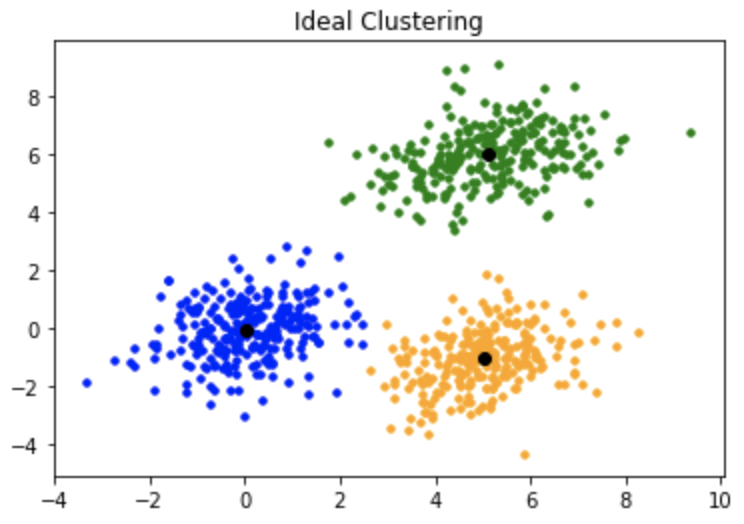


###Where is K-means clustering used?

kmeans algorithm is very popular and used in a variety of applications such as market segmentation, document clustering, image segmentation and image compression, etc. The goal usually when we undergo a cluster analysis is either: Get a meaningful intuition of the structure of the data we're dealing with.



In [ ]:
k_means = KMeans(n_clusters=2)
k_means.fit(data)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=2)

In [ ]:
np.unique(k_means.labels_)

array([0, 1], dtype=int32)

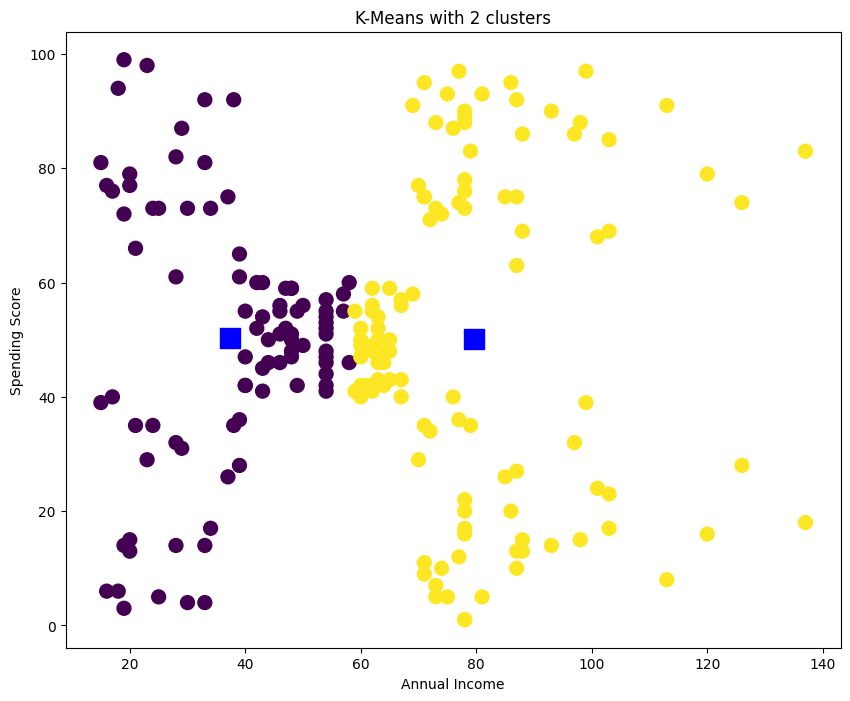

In [ ]:
plt.figure(figsize=(10, 8))
centers = k_means.cluster_centers_
plt.scatter(data['Annual Income (k$)'],
            data['Spending Score (1-100)'],
            c=k_means.labels_, s=100)

plt.scatter(centers[:,0], centers[:,1], color='blue', marker='s', s=200)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('K-Means with 2 clusters')

plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score (data, k_means.labels_)

print("Score = ", score)

Score =  0.2968969162503008


/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:8

Text(0.5, 1.0, 'Elbow plot for optimal number of clusters')

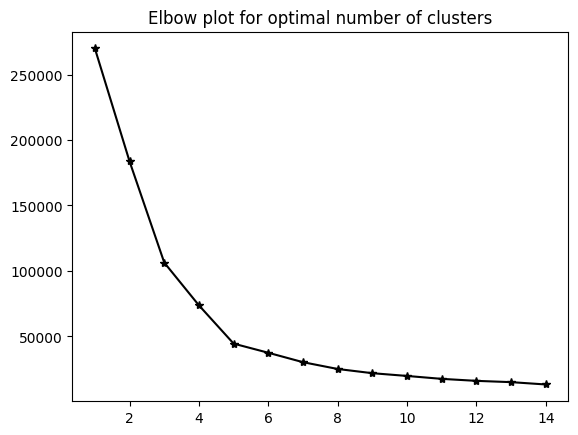

In [ ]:
wscc = []
for i in range(1,15):
    kmeans = KMeans(n_clusters=i, init="k-means++",random_state=0)
    kmeans.fit(data)
    wscc.append(kmeans.inertia_)

plt.plot(range(1,15),wscc,marker="*",c="black")
plt.title("Elbow plot for optimal number of clusters")

In [ ]:
k_means = KMeans(n_clusters=5)
k_means.fit(data)

/usr/local/lib/python3.10/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


KMeans(n_clusters=5)

In [ ]:
np.unique(k_means.labels_)

array([0, 1, 2, 3, 4], dtype=int32)

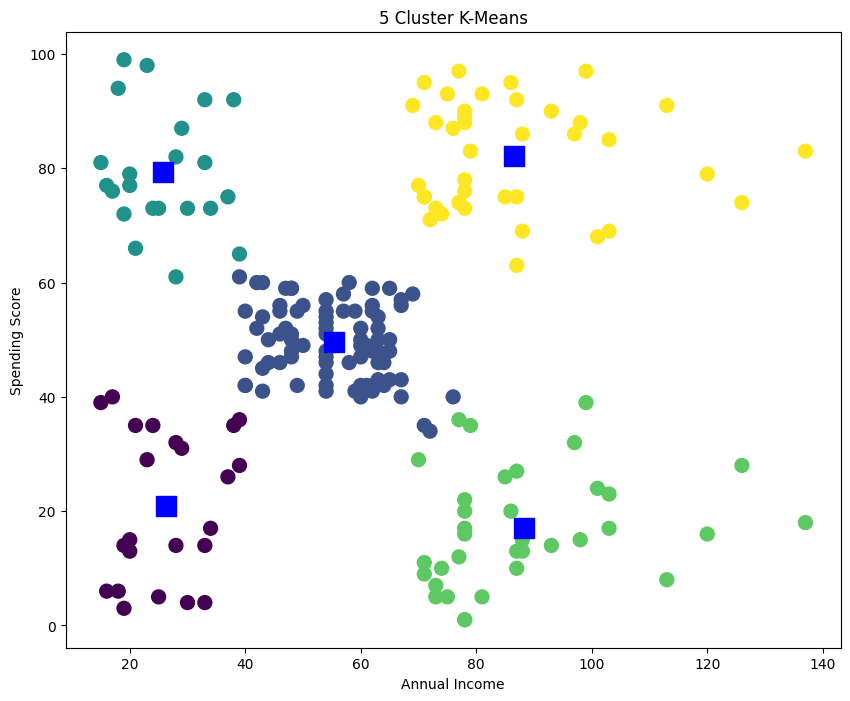

In [ ]:
plt.figure(figsize=(10, 8))
centers = k_means.cluster_centers_
plt.scatter(data['Annual Income (k$)'],
            data['Spending Score (1-100)'],
            c=k_means.labels_, s=100)

plt.scatter(centers[:,0], centers[:,1], color='blue', marker='s', s=200)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('5 Cluster K-Means')

plt.show()

## Performance Metric for Clustering :
### Silhouette Score -

The silhouette score is a metric used to measure the quality of clusters in a clustering algorithm. It quantifies how similar an object is to its own cluster (cohesion) compared to other clusters (separation). A higher silhouette score indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.

The silhouette score ranges from -1 to 1, where:
- A score close to +1 indicates that the object is well inside its own cluster and far from neighboring clusters.
- A score close to 0 indicates that the object is on or very close to the decision boundary between two neighboring clusters.
- A score close to -1 indicates that the object is likely placed in the wrong cluster.

Here's the formula for calculating the silhouette score for a single data point:

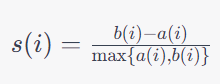


Where:
- s(i)  is the silhouette score for data point \( i \).
- a(i) is the average distance from \( i \) to other data points in the same cluster.
-  b(i) is the smallest average distance from \( i \) to data points in a different cluster, minimized over clusters.

Here's an example of how to calculate the silhouette score for a single data point:

Suppose we have a data point ( i ) with features [5, 3] and two clusters. The distances to other data points in the same cluster a(i) and the smallest average distance to data points in a different cluster  b(i)  are as follows:


Cluster A: [4, 3], [5, 2], [6, 3]

Cluster B: [1, 2], [2, 3], [3, 3]


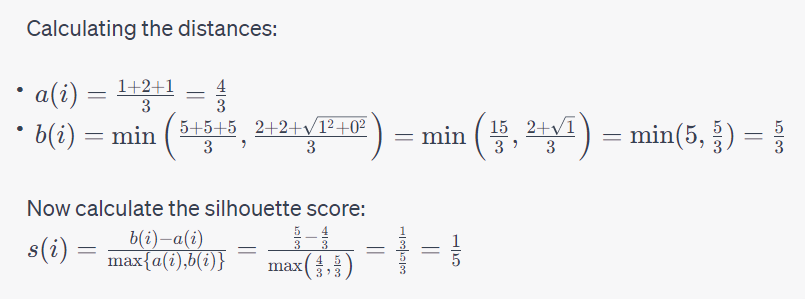


So, for this data point, the silhouette score is \( \frac{1}{5} \), indicating that it is relatively closer to its own cluster than to other clusters.

In [ ]:
score = metrics.silhouette_score(data, k_means.labels_)

print("Score = ", score)

Score =  0.553931997444648


## 2- Agglomerative Clustering

The agglomerative clustering is the most common type of hierarchical clustering used to group objects in clusters based on their similarity. It's also known as AGNES (Agglomerative Nesting). The algorithm starts by treating each object as a singleton cluster.

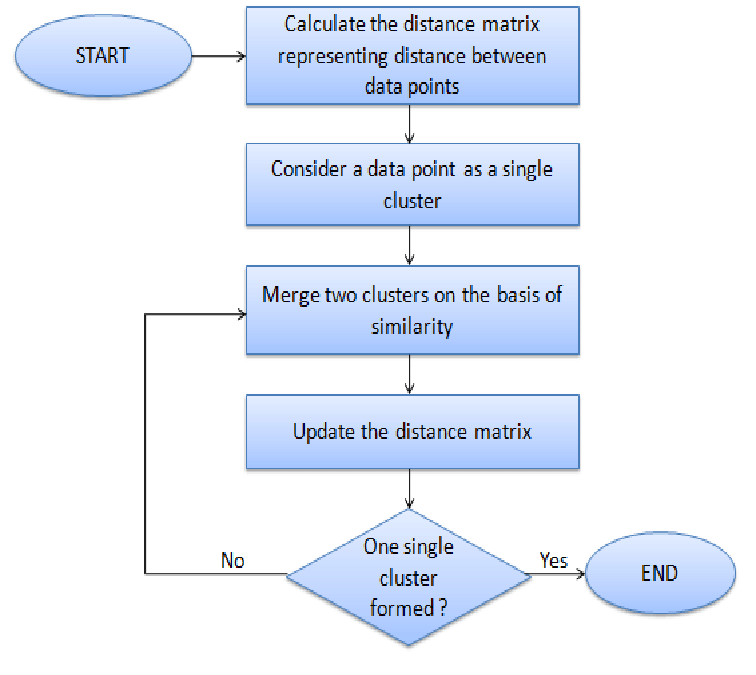

In [ ]:
model_agg = AgglomerativeClustering(n_clusters=5)
#
yhat_agg = model_agg.fit_predict(data)
clusters_agg = unique(yhat_agg)
print("Clusters of Mini Batch KMeans.",clusters_agg)
labels_agg = model_agg.labels_

Clusters of Mini Batch KMeans. [0 1 2 3 4]


In [ ]:
score_agg = metrics.silhouette_score(data,labels_agg)

print("Score of Mean Shift = ", score_agg)

Score of Mean Shift =  0.5529945955148896
